# Laboratoire 2 -- Actionneur a bobine mobile

**Identification experimentale des 6 parametres** d'un VCM (Voice Coil Motor) miniature, du type utilise pour le positionnement des tetes de lecture des disques durs.

## Plan

1. **EX1** -- Reponse indicielle bobine bloquee : extraction de R et L par fit exponentiel.
2. **EX2** -- Oscillations libres bobine ouverte : extraction de delta, omega_d et K_u par detection des extrema.
3. **EX3** -- Oscillations libres bobine court-circuitee : extraction de delta', omega_d' (sur le signal courant, avec retrait de l'offset DC).
4. **Synthese** -- Calcul de J, C_v, K_r, et du nombre de spires N.
5. **Validation** -- Superposition mesure/modele analytique pour chaque essai.

Toutes les figures finales sont sauvees dans `rapport/images/` et reprises directement dans le PDF du rapport.

## Imports et constantes


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ASSETS = Path("assets")
IMG_DIR = Path("rapport/images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Donnees physiques de l'enonce
DAMAX_DEG = 17.1
DAMAX = np.deg2rad(DAMAX_DEG)
CURRENT_GAIN = 1.0           # A/V (sonde TCPA300/312)
B_FIELD = 0.45               # T (entrefer)
R_EXT, R_INT = 0.030, 0.015  # m (rayons bobine)

FILES = {
    "ex1_moving":      ASSETS / "T0000ALL.CSV",
    "ex1_blocked":     ASSETS / "T0001ALL.CSV",
    "ex2_right_open":  ASSETS / "T0002CH1.CSV",
    "ex2_left_open":   ASSETS / "T0003CH1.CSV",
    "ex3_right_short": ASSETS / "T0004CH1.CSV",
    "ex3_left_short":  ASSETS / "T0005CH1.CSV",
}

## Fonctions utilitaires

Trois primitives reutilisees partout : chargement CSV Tektronix, moyenne glissante, et detection alternee max/min.

In [2]:
def load_tek(path: Path) -> pd.DataFrame:
    """Charge un CSV Tektronix DPO2014B (15 lignes d'en-tete, separateur virgule)."""
    df = pd.read_csv(path, skiprows=15)
    df.columns = [c.strip() for c in df.columns]
    return df.apply(pd.to_numeric, errors="coerce")


def moving_average(y, window: int) -> np.ndarray:
    """Moyenne glissante sur ``window`` echantillons (mode 'same')."""
    if window <= 1:
        return np.asarray(y, dtype=float).copy()
    return np.convolve(np.asarray(y, dtype=float), np.ones(window) / window, mode="same")


def find_alternating_extrema(y: np.ndarray, min_distance: int) -> np.ndarray:
    """Indices des extrema locaux *alternes* (max, min, max, ...).

    Espaces d'au moins ``min_distance`` echantillons. On garde le plus extreme
    si plusieurs candidats du meme signe se presentent dans la fenetre.
    """
    y = np.asarray(y, dtype=float)
    extrema, last_idx, last_sign = [], -10**9, 0
    for i in range(1, len(y) - 1):
        is_max = y[i - 1] < y[i] > y[i + 1]
        is_min = y[i - 1] > y[i] < y[i + 1]
        if not (is_max or is_min):
            continue
        sign = +1 if is_max else -1
        if i - last_idx < min_distance:
            if sign == last_sign and (
                (sign == +1 and y[i] > y[last_idx]) or (sign == -1 and y[i] < y[last_idx])
            ):
                extrema[-1] = (i, sign)
                last_idx = i
            continue
        if last_sign != 0 and sign == last_sign:
            if (sign == +1 and y[i] > y[last_idx]) or (sign == -1 and y[i] < y[last_idx]):
                extrema[-1] = (i, sign)
                last_idx = i
            continue
        extrema.append((i, sign))
        last_idx, last_sign = i, sign
    return np.array([e[0] for e in extrema], dtype=int)

## EX1 -- Parametres electriques R et L

**Strategie.** L'essai bloque (`T0001ALL.CSV`) impose `dot(alpha) = 0`, donc la f.c.e.m. K_u*dot(alpha) est nulle et l'equation electrique se reduit a un simple circuit RL :
$$u(t) = R\,i(t) + L\,\frac{di}{dt}.$$
La reponse au saut est :
$$i(t) = \frac{u_0}{R}\bigl(1 - e^{-t/\tau_{el}}\bigr), \qquad \tau_{el} = L/R.$$
On obtient $R = \Delta u / \Delta i_\infty$ et $L = R\,\tau_{el}$.

**Note importante.** L'essai *avec mouvement* (`T0000ALL.CSV`) ne donne pas R et L proprement : la f.c.e.m. perturbe la reponse en courant. On l'utilise uniquement pour illustrer son effet.

**Detection du front.** Pour eviter l'artefact de bord du moving-average (qui peut produire de faux pics de derivee en fin de tableau), on detecte le front par passage de seuil sur la **valeur** de la tension, pas sur sa derivee.

In [3]:
def estimate_rl_blocked(path: Path) -> dict:
    """R et L par fit exponentiel sur l'essai bloque (sans f.c.e.m.)."""
    df = load_tek(path)
    t = df["TIME"].to_numpy(dtype=float)
    u = df["CH1"].to_numpy(dtype=float)
    i = df["CH2"].to_numpy(dtype=float) * CURRENT_GAIN

    # Front detecte sur la valeur (pas la derivee)
    threshold = (np.nanmax(u) + np.nanmin(u)) / 2
    idx_step = int(np.argmax(u > threshold))
    t0 = t[idx_step]

    # Plateaux avant / apres le front
    pre  = t < t0 - 5e-6
    post = t > t0 + 200e-6
    u0, u1 = float(np.mean(u[pre])), float(np.mean(u[post]))
    i0, i1 = float(np.mean(i[pre])), float(np.mean(i[post]))
    R = (u1 - u0) / (i1 - i0)

    # Constante de temps par regression log sur la montee
    fit_mask = (t >= t0) & (t <= t0 + 100e-6)
    z = i1 - i[fit_mask]
    valid = (z > 1e-4) & np.isfinite(z)
    slope, intercept = np.polyfit(t[fit_mask][valid] - t0, np.log(z[valid]), 1)
    tau = -1.0 / slope
    L = R * tau

    return dict(t=t, u=u, i=i, t0=t0, idx_step=idx_step,
                u0=u0, u1=u1, i0=i0, i1=i1, R=R, tau=tau, L=L,
                slope=slope, intercept=intercept, i_inf=i1)


def estimate_rl_moving(path: Path) -> dict:
    """R apparent sur l'essai en mouvement (a titre comparatif)."""
    df = load_tek(path)
    t = df["TIME"].to_numpy(dtype=float)
    u = df["CH1"].to_numpy(dtype=float)
    i = df["CH2"].to_numpy(dtype=float) * CURRENT_GAIN
    threshold = (np.nanmax(u) + np.nanmin(u)) / 2
    idx_step = int(np.argmax(u > threshold))
    t0 = t[idx_step]
    pre  = t < t0 - 5e-6
    post = t > t0 + 200e-6
    u0, u1 = float(np.mean(u[pre])), float(np.mean(u[post]))
    i0, i1 = float(np.mean(i[pre])), float(np.mean(i[post]))
    R = (u1 - u0) / (i1 - i0)
    return dict(t=t, u=u, i=i, t0=t0, u0=u0, u1=u1, i0=i0, i1=i1, R=R)

In [4]:
blocked = estimate_rl_blocked(FILES["ex1_blocked"])
moving  = estimate_rl_moving(FILES["ex1_moving"])

print(f"R       = {blocked['R']:.2f} ohm    (essai bloque, retenu)")
print(f"tau_el  = {blocked['tau']*1e6:.1f} us")
print(f"L       = {blocked['L']*1e3:.3f} mH")
print(f"R (mvt) = {moving['R']:.2f} ohm    (essai mvt, biais f.c.e.m.)")
print(f"\ni_max mesure = {blocked['i_inf']*1e3:.1f} mA  -> {'OK' if blocked['i_inf']<0.2 else 'DEPASSE'} (limite thermique 200 mA)")

R       = 25.31 ohm    (essai bloque, retenu)
tau_el  = 121.3 us
L       = 3.070 mH
R (mvt) = 24.21 ohm    (essai mvt, biais f.c.e.m.)

i_max mesure = 149.2 mA  -> OK (limite thermique 200 mA)


### Figures EX1


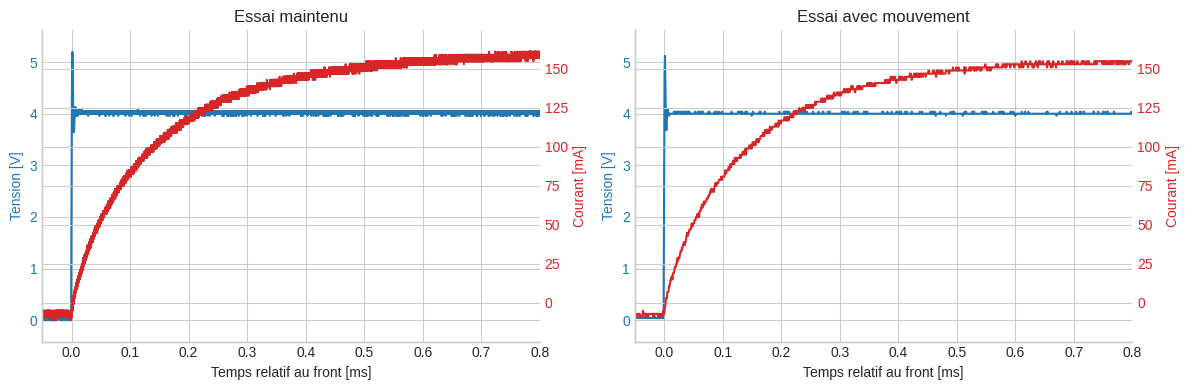

In [5]:
def fig_ex1_overview(blocked, moving, savepath):
    xlim = (-0.05, 0.8)
    datasets = [(blocked, "Essai maintenu"), (moving, "Essai avec mouvement")]

    u_vals, i_vals = [], []
    for data, _ in datasets:
        t_ms = (data["t"] - data["t0"]) * 1e3
        mask = (t_ms >= xlim[0]) & (t_ms <= xlim[1])
        u_vals.append(data["u"][mask])
        i_vals.append(data["i"][mask] * 1e3)
    u_vals = np.concatenate(u_vals)
    i_vals = np.concatenate(i_vals)
    u_margin = 0.08 * (u_vals.max() - u_vals.min())
    i_margin = 0.08 * (i_vals.max() - i_vals.min())
    u_ylim = (u_vals.min() - u_margin, u_vals.max() + u_margin)
    i_ylim = (i_vals.min() - i_margin, i_vals.max() + i_margin)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (data, title) in zip(axes, datasets):
        t_ms = (data["t"] - data["t0"]) * 1e3
        ax.plot(t_ms, data["u"], color="tab:blue", label=r"$u(t)$ [V]")
        ax2 = ax.twinx()
        ax2.plot(t_ms, data["i"] * 1e3, color="tab:red", label=r"$i(t)$ [mA]")
        ax.set_xlabel("Temps relatif au front [ms]")
        ax.set_ylabel("Tension [V]", color="tab:blue")
        ax2.set_ylabel("Courant [mA]", color="tab:red")
        ax.set_title(title)
        ax.set_xlim(*xlim)
        ax.set_ylim(*u_ylim)
        ax2.set_ylim(*i_ylim)
        ax.tick_params(axis="y", labelcolor="tab:blue")
        ax2.tick_params(axis="y", labelcolor="tab:red")
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()

fig_ex1_overview(blocked, moving, IMG_DIR / "fig_ex1_overview.pdf")

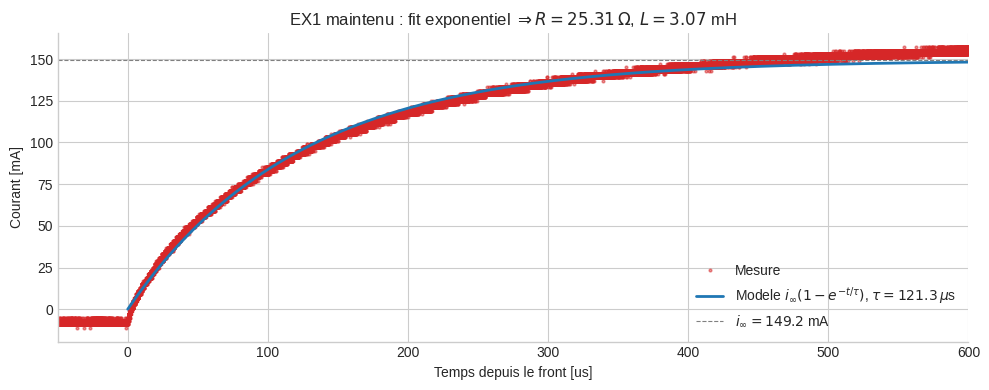

In [6]:
def fig_ex1_blocked_fit(b, savepath):
    """Zoom sur la montee + fit exponentiel pour valider le modele RL."""
    t, i, t0 = b["t"], b["i"], b["t0"]
    R, L, tau, i_inf = b["R"], b["L"], b["tau"], b["i_inf"]
    mask = (t >= t0 - 50e-6) & (t <= t0 + 600e-6)
    t_loc = (t[mask] - t0) * 1e6
    t_model = np.linspace(0, 600e-6, 600)
    i_model = i_inf * (1 - np.exp(-t_model / tau))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_loc, i[mask] * 1e3, "o", ms=2, alpha=0.5, color="tab:red", label="Mesure")
    ax.plot(t_model * 1e6, i_model * 1e3, lw=2, color="tab:blue",
            label=fr"Modele $i_\infty(1-e^{{-t/\tau}})$, $\tau={tau*1e6:.1f}\,\mu$s")
    ax.axhline(i_inf * 1e3, color="grey", ls="--", lw=0.8, label=fr"$i_\infty={i_inf*1e3:.1f}$ mA")
    ax.set_xlabel("Temps depuis le front [us]")
    ax.set_ylabel("Courant [mA]")
    ax.set_title(fr"EX1 maintenu : fit exponentiel $\Rightarrow R={R:.2f}\,\Omega$, $L={L*1e3:.2f}$ mH")
    ax.legend(loc="lower right")
    ax.set_xlim(-50, 600)
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()

fig_ex1_blocked_fit(blocked, IMG_DIR / "fig_ex1_blocked_fit.pdf")

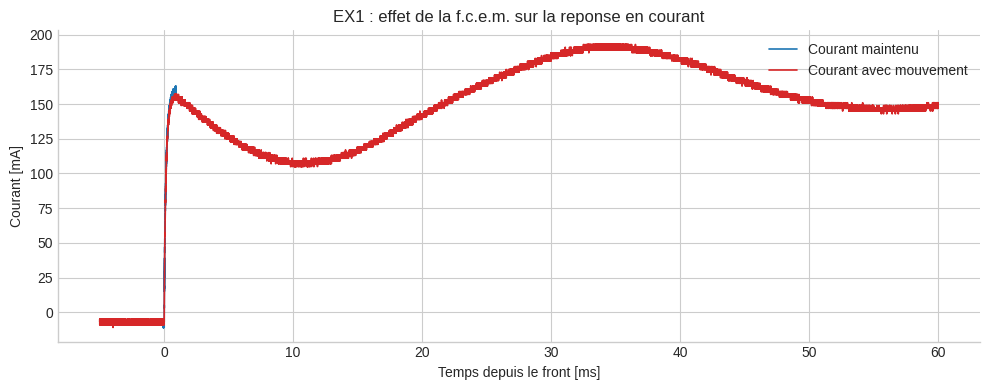

In [7]:
def fig_ex1_compare(blocked, moving, savepath):
    """Comparaison sur 60 ms pour mettre en evidence l'effet de la f.c.e.m."""
    fig, ax = plt.subplots(figsize=(10, 4))
    for data, label, color in [(blocked, "maintenu",       "tab:blue"),
                               (moving,  "avec mouvement", "tab:red")]:
        t, i, t0 = data["t"], data["i"], data["t0"]
        mask = (t >= t0 - 5e-3) & (t <= t0 + 60e-3)
        ax.plot((t[mask] - t0) * 1e3, i[mask] * 1e3, color=color, lw=1.2, label=f"Courant {label}")
    ax.set_xlabel("Temps depuis le front [ms]")
    ax.set_ylabel("Courant [mA]")
    ax.set_title("EX1 : effet de la f.c.e.m. sur la reponse en courant")
    ax.legend()
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()

fig_ex1_compare(blocked, moving, IMG_DIR / "fig_ex1_compare.pdf")

## EX2 et EX3 -- Oscillations amorties

**Modele.** Avec conditions initiales $\alpha(0) = \Delta\alpha_{max}$, $\dot\alpha(0) = 0$ :
$$\alpha(t) = \Delta\alpha_{max}\,e^{-\delta t}\!\left[\cos(\omega_d t) + \tfrac{\delta}{\omega_d}\sin(\omega_d t)\right],\quad \dot\alpha(t) = -\Delta\alpha_{max}\,\tfrac{\omega_n^2}{\omega_d}\,e^{-\delta t}\sin(\omega_d t).$$

**Strategie d'analyse :**
1. Lisser le signal (fenetre 2 ms : on garde la dynamique mecanique a ~20 Hz et on rejette le bruit haute frequence).
2. **Centrer le signal** (retrait de la moyenne) : indispensable en EX3 ou la sonde TCPA presente un offset DC, sans quoi seuls les extrema d'un cote sont detectes -> fausse periode.
3. Detecter les extrema locaux *alternes* (max, min, max, ...) espaces d'au moins 15 ms.
4. Pseudo-pulsation : intervalle entre extrema consecutifs = $T_d / 2$.
5. Coefficient d'amortissement : regression log-lineaire sur les amplitudes des extrema, $\log|y_k| = -\delta\,t_k + \text{cst}$.
6. Enveloppe extrapolee a l'instant du lacher (1/4 periode avant le 1er pic) -> donne $U_{env,0}$ ou $I_{env,0}$.

**Pourquoi cette procedure ?** Le rapport precedent utilisait un `min_distance` trop court (~1.5 ms) et des pics absolus de `|y|` non centres : le bruit faisait detecter de faux pics tous les 1.5 ms, donnant une frequence apparente de 305 Hz au lieu de la vraie ~19 Hz.

In [8]:
def fit_damped_sine(t, y, label, t_min, t_max,
                    smooth_ms=2.0, min_dist_ms=15.0):
    """Extrait delta, omega_d, omega_n et l'enveloppe au lacher."""
    dt = float(np.median(np.diff(t)))
    w_smooth   = max(3, int(smooth_ms   * 1e-3 / dt))
    w_min_dist = max(3, int(min_dist_ms * 1e-3 / dt))

    y_smooth = moving_average(y, w_smooth)

    mask = (t >= t_min) & (t <= t_max)
    tw = t[mask]
    yw = y_smooth[mask]
    yw_centered = yw - float(np.mean(yw))   # <-- retrait DC essentiel

    extrema = find_alternating_extrema(yw_centered, w_min_dist)
    if len(extrema) < 4:
        raise RuntimeError(f"Pas assez d'extrema sur {label} ({len(extrema)})")

    peak_t   = tw[extrema]
    peak_y   = yw_centered[extrema]
    peak_abs = np.abs(peak_y)
    keep = peak_abs > 0.04 * peak_abs.max()
    peak_t, peak_y, peak_abs = peak_t[keep], peak_y[keep], peak_abs[keep]

    n = min(len(peak_t), 12)
    half_T  = float(np.mean(np.diff(peak_t[:n])))   # = T_d / 2
    full_T  = 2.0 * half_T
    omega_d = 2.0 * np.pi / full_T

    slope, intercept = np.polyfit(peak_t, np.log(peak_abs), 1)
    delta   = float(-slope)
    omega_n = float(np.sqrt(omega_d**2 + delta**2))

    t_release   = peak_t[0] - np.pi / (2.0 * omega_d)
    env_release = float(np.exp(intercept + slope * t_release))

    return dict(
        label=label, delta=delta, omega_d=omega_d, omega_n=omega_n,
        full_T=full_T, env_release=env_release, t_release=t_release,
        peak_t=peak_t, peak_y=peak_y, dc_offset=float(np.mean(yw)),
        slope=slope, intercept=intercept,
        t=t, y=y, y_smooth=y_smooth, mask=mask,
        Cv_over_J=2*delta, Kr_over_J=omega_n**2,
    )


def fig_oscillation(result, savepath, ylabel, title, color="tab:blue"):
    """Trace le signal lisse, les extrema detectes et l'enveloppe."""
    t, y_smooth, mask = result["t"], result["y_smooth"], result["mask"]
    peak_t = result["peak_t"]
    peak_y = result["peak_y"] + result["dc_offset"]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(t[mask] * 1e3, y_smooth[mask], color=color, lw=1, label="Signal lisse")
    ax.scatter(peak_t * 1e3, peak_y, color="tab:red", s=22, zorder=5, label="Extrema detectes")
    t_env = np.linspace(peak_t.min(), peak_t.max(), 200)
    env_pos =  np.exp(result["intercept"] + result["slope"] * t_env) + result["dc_offset"]
    env_neg = -np.exp(result["intercept"] + result["slope"] * t_env) + result["dc_offset"]
    ax.plot(t_env * 1e3, env_pos, "k--", lw=0.9, alpha=0.7,
            label=fr"Enveloppe $\propto e^{{-{result['delta']:.2f}\,t}}$")
    ax.plot(t_env * 1e3, env_neg, "k--", lw=0.9, alpha=0.7)
    ax.set_xlabel("Temps [ms]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()

## EX2 -- Bobine ouverte

Bobine en circuit ouvert, $i = 0$. Aux bornes on mesure directement $u_{im}(t) = K_u\,\dot\alpha(t)$.
Deux essais : position extreme droite (`T0002`) et gauche (`T0003`).

In [9]:
def run_oscillating_test(path, label, t_min, t_max):
    df = load_tek(path)
    return fit_damped_sine(df["TIME"].to_numpy(), df["CH1"].to_numpy(),
                           label, t_min, t_max)

ex2_droite = run_oscillating_test(FILES["ex2_right_open"], "Droite",  0.005, 0.350)
ex2_gauche = run_oscillating_test(FILES["ex2_left_open"],  "Gauche", -0.020, 0.330)

ex2_table = pd.DataFrame([
    {
        "essai":          r["label"],
        "delta [rad/s]":  r["delta"],
        "omega_d [rad/s]":r["omega_d"],
        "T_d [ms]":       r["full_T"] * 1e3,
        "f_d [Hz]":       1 / r["full_T"],
        "U_env(0) [V]":   r["env_release"],
    }
    for r in (ex2_droite, ex2_gauche)
])
ex2_table

,essai,delta [rad/s],omega_d [rad/s],T_d [ms],f_d [Hz],U_env(0) [V]
0,Droite,3.110804,117.989659,53.252000,18.778637,2.665978
1,Gauche,3.241063,117.818373,53.329418,18.751377,2.356275


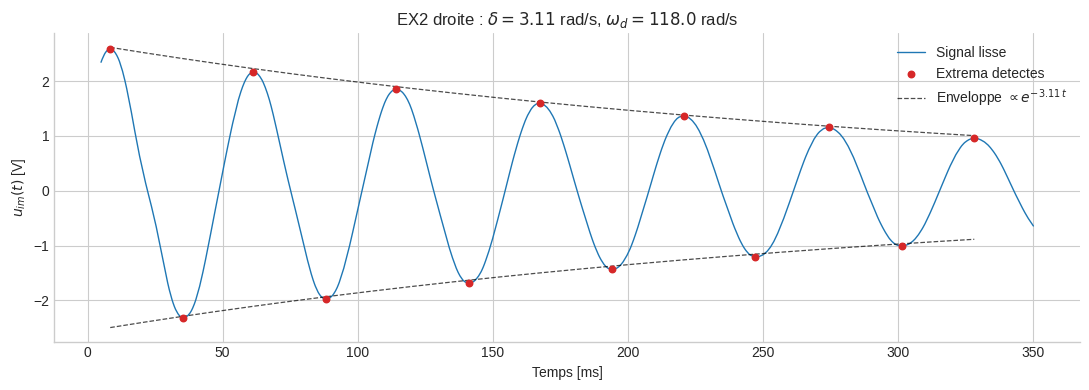

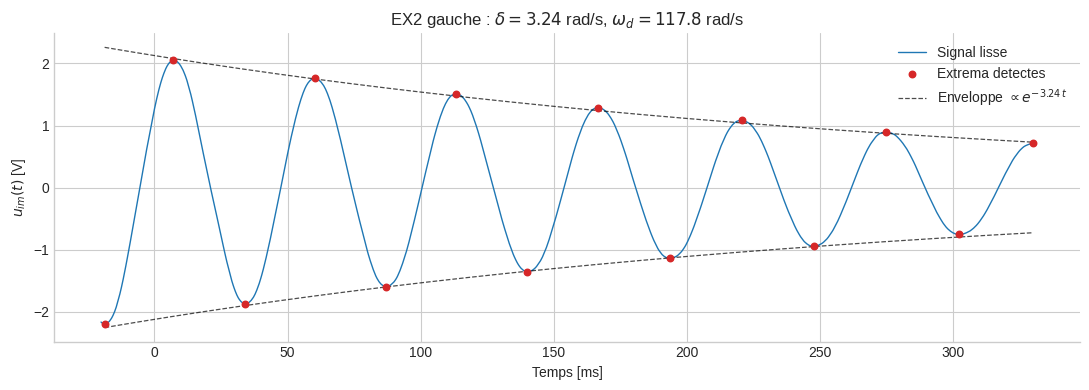

In [10]:
fig_oscillation(ex2_droite, IMG_DIR / "fig_ex2_droite.pdf",
                r"$u_{im}(t)$ [V]",
                f"EX2 droite : $\\delta={ex2_droite['delta']:.2f}$ rad/s, "
                f"$\\omega_d={ex2_droite['omega_d']:.1f}$ rad/s")
fig_oscillation(ex2_gauche, IMG_DIR / "fig_ex2_gauche.pdf",
                r"$u_{im}(t)$ [V]",
                f"EX2 gauche : $\\delta={ex2_gauche['delta']:.2f}$ rad/s, "
                f"$\\omega_d={ex2_gauche['omega_d']:.1f}$ rad/s")

## EX3 -- Bobine court-circuitee

Les bornes de la bobine sont reliees par la sonde de courant. En negligeant $L\,di/dt$ (justifie a posteriori par $\tau_{el} \ll \tau_{mec}$, voir synthese), on a :
$$i(t) \approx -\tfrac{K_u}{R}\,\dot\alpha(t) = \tfrac{K_u\,\Delta\alpha_{max}}{R}\,\tfrac{\omega_n^2}{\omega_d'}\,e^{-\delta' t}\sin(\omega_d' t).$$
L'amortissement effectif augmente :
$$\delta' = \delta + \tfrac{K_u^2}{2 J R}.$$
L'ecart $\delta' - \delta$ donne directement J (voir synthese).

**Attention** : le signal courant a un offset DC residuel (~10 mV) -- d'ou l'importance du centrage dans `fit_damped_sine`.

In [11]:
ex3_droite = run_oscillating_test(FILES["ex3_right_short"], "Droite",  0.005, 0.170)
ex3_gauche = run_oscillating_test(FILES["ex3_left_short"],  "Gauche", -0.020, 0.170)

ex3_table = pd.DataFrame([
    {
        "essai":            r["label"],
        "delta' [rad/s]":   r["delta"],
        "omega_d' [rad/s]": r["omega_d"],
        "T_d' [ms]":        r["full_T"] * 1e3,
        "f_d' [Hz]":        1 / r["full_T"],
        "DC offset [mV]":   r["dc_offset"] * 1e3,
    }
    for r in (ex3_droite, ex3_gauche)
])
ex3_table

,essai,delta' [rad/s],omega_d' [rad/s],T_d' [ms],f_d' [Hz],DC offset [mV]
0,Droite,18.256626,96.933297,64.819680,15.427413,-2.943336
1,Gauche,34.079005,112.246774,55.976533,17.864629,-10.819847


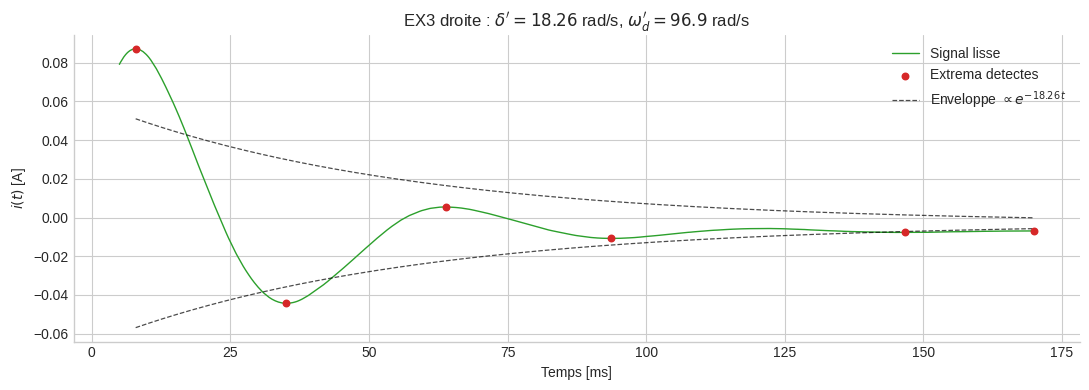

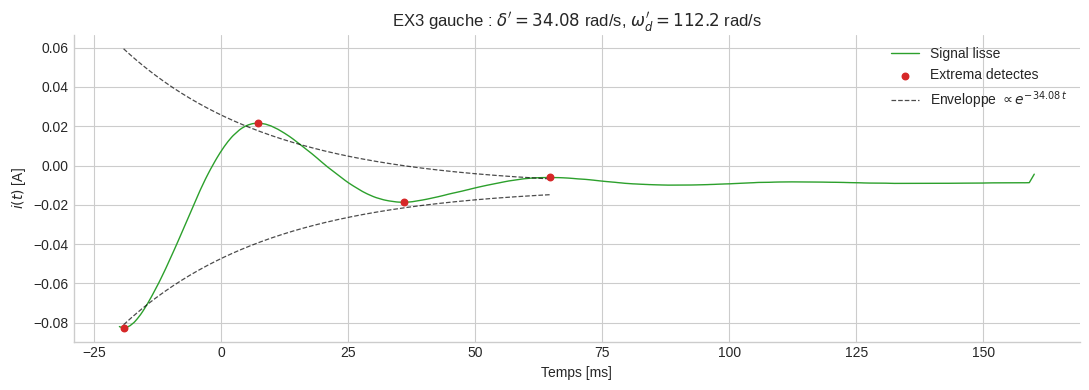

In [12]:
fig_oscillation(ex3_droite, IMG_DIR / "fig_ex3_droite.pdf",
                r"$i(t)$ [A]",
                f"EX3 droite : $\\delta'={ex3_droite['delta']:.2f}$ rad/s, "
                f"$\\omega_d'={ex3_droite['omega_d']:.1f}$ rad/s",
                color="tab:green")
fig_oscillation(ex3_gauche, IMG_DIR / "fig_ex3_gauche.pdf",
                r"$i(t)$ [A]",
                f"EX3 gauche : $\\delta'={ex3_gauche['delta']:.2f}$ rad/s, "
                f"$\\omega_d'={ex3_gauche['omega_d']:.1f}$ rad/s",
                color="tab:green")

## Synthese -- Calcul des 6 parametres + nombre de spires

On utilise la moyenne droite/gauche pour chaque grandeur.

$$K_u = \frac{U_{env,0}\,\omega_d}{\Delta\alpha_{max}\,\omega_n^2} \approx \frac{U_{env,0}}{\Delta\alpha_{max}\,\omega_n}$$

$$J = \frac{K_u^2}{2\,R\,(\delta' - \delta)}, \quad C_v = 2 J \delta, \quad K_r = J\,\omega_n^2$$

Pour le nombre de spires (donnee §2.2.4-3, $B = 0{,}45$ T, $r_{ext} = 30$ mm, $r_{int} = 15$ mm) :
$$K_t = N\,B\,(r_{ext}^2 - r_{int}^2) \;\Rightarrow\; N = \frac{K_t}{B\,(r_{ext}^2 - r_{int}^2)}.$$

In [13]:
R, L = blocked["R"], blocked["L"]

# Moyennes EX2 / EX3
delta   = 0.5 * (ex2_droite["delta"]   + ex2_gauche["delta"])
omega_d = 0.5 * (ex2_droite["omega_d"] + ex2_gauche["omega_d"])
omega_n = 0.5 * (ex2_droite["omega_n"] + ex2_gauche["omega_n"])
Uenv0   = 0.5 * (ex2_droite["env_release"] + ex2_gauche["env_release"])

delta_p   = 0.5 * (ex3_droite["delta"]   + ex3_gauche["delta"])
omega_d_p = 0.5 * (ex3_droite["omega_d"] + ex3_gauche["omega_d"])

# Calculs
Ku = Uenv0 / (DAMAX * omega_n)
J  = Ku**2 / (2 * R * (delta_p - delta))
Cv = 2 * J * delta
Kr = J * omega_n**2
N  = Ku / (B_FIELD * (R_EXT**2 - R_INT**2))

synth = pd.DataFrame([
    ("R",       R,    "ohm",       "EX1 maintenu"),
    ("L",       L,    "H",         "EX1 maintenu"),
    ("K_u=K_t", Ku,   "V.s/rad",   "EX2"),
    ("J",       J,    "kg.m^2",    "EX2 + EX3"),
    ("C_v",     Cv,   "N.m.s/rad", "EX2 + EX3"),
    ("K_r",     Kr,   "N.m/rad",   "EX2 + EX3"),
    ("N",       N,    "spires",    "EX2 + geometrie"),
], columns=["parametre", "valeur", "unite", "source"])
synth

,parametre,valeur,unite,source
0,R,25.305260,ohm,EX1 maintenu
1,L,0.003070,H,EX1 maintenu
2,K_u=K_t,0.071336,V.s/rad,EX2
3,J,0.000004,kg.m^2,EX2 + EX3
4,C_v,0.000028,N.m.s/rad,EX2 + EX3
5,K_r,0.060838,N.m/rad,EX2 + EX3
6,N,234.851139,spires,EX2 + geometrie


In [14]:
# Verifications de coherence physique
tau_el  = L / R
tau_mec = 1 / delta

print("=== Verifications ===")
print(f"omega_n / delta  (EX2)      = {omega_n/delta:6.1f}    (>>1 -> sous-amorti)")
print(f"omega_n / delta' (EX3)      = {omega_n/delta_p:6.1f}    (>1 mais limite)")
print(f"tau_el                      = {tau_el*1e6:6.1f} us")
print(f"tau_mec                     = {tau_mec*1e3:6.1f} ms")
print(f"tau_el / tau_mec            = {tau_el/tau_mec:.2e}  (<<1 -> separation OK)")
print()
print(f"Couple a la butee : K_r * Damax = {Kr*DAMAX*1e3:.1f} mN.m")
print(f"Courant statique requis        = {Kr*DAMAX/Ku*1e3:.0f} mA  (limite thermique : 200 mA)")
print(f"Freinage electromag / visqueux : {(delta_p-delta)/delta:.1f}x")

=== Verifications ===
omega_n / delta  (EX2)      =   37.1    (>>1 -> sous-amorti)
omega_n / delta' (EX3)      =    4.5    (>1 mais limite)
tau_el                      =  121.3 us
tau_mec                     =  314.9 ms
tau_el / tau_mec            = 3.85e-04  (<<1 -> separation OK)

Couple a la butee : K_r * Damax = 18.2 mN.m
Courant statique requis        = 255 mA  (limite thermique : 200 mA)
Freinage electromag / visqueux : 7.2x


## Validation -- superposition mesure / modele analytique

On reprend les expressions analytiques avec les parametres identifies et on les superpose aux mesures.

EX2 : $u_{im}(t) = -K_u\,\Delta\alpha_{max}\,\frac{\omega_n^2}{\omega_d}\,e^{-\delta t}\sin(\omega_d t)$

EX3 : $i(t) = +\frac{K_u\,\Delta\alpha_{max}}{R}\,\frac{\omega_n^2}{\omega_d'}\,e^{-\delta' t}\sin(\omega_d' t)$

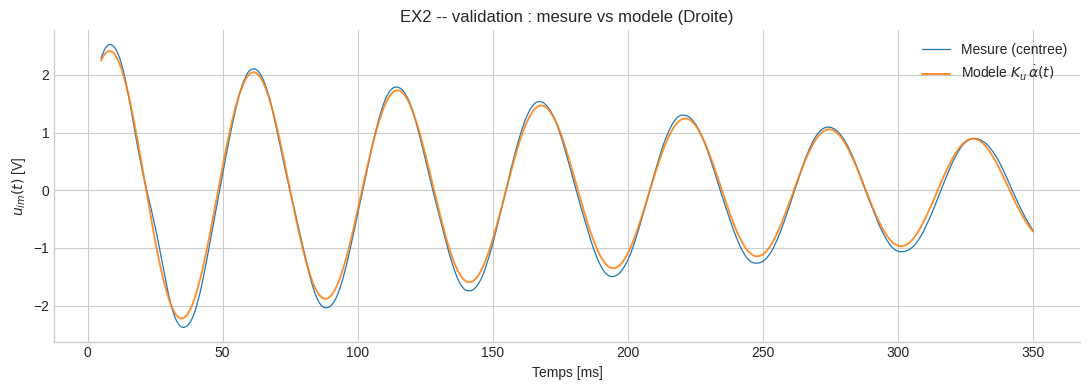

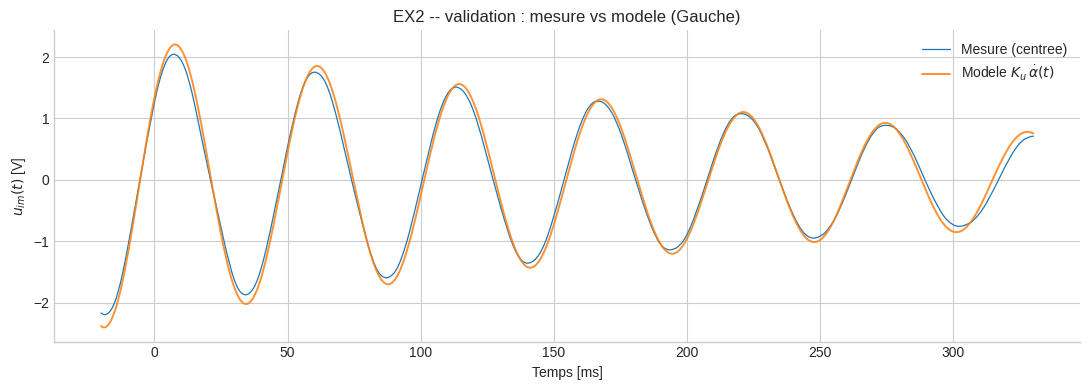

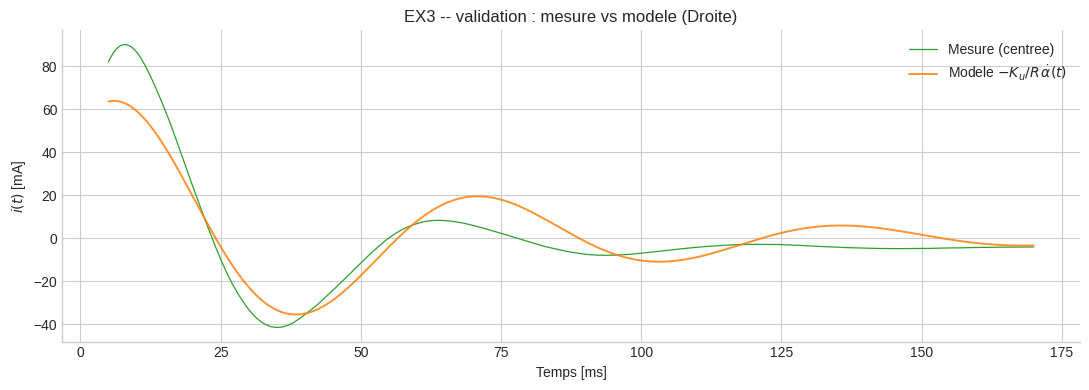

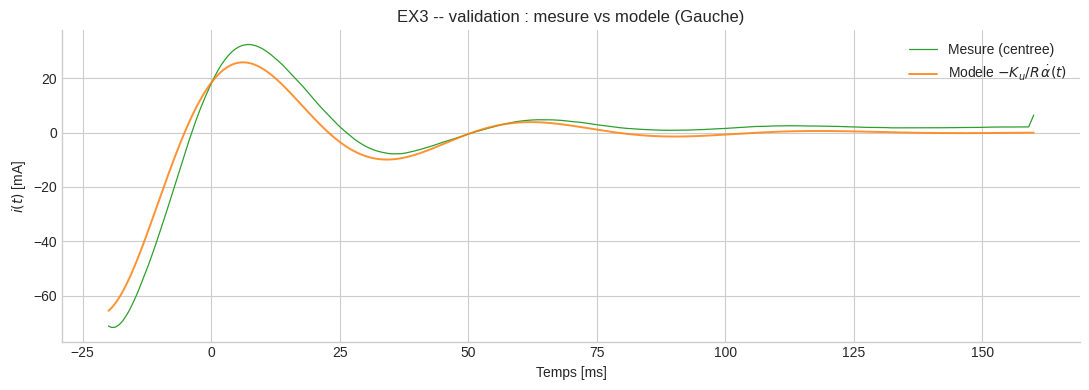

In [15]:
def fig_validation_ex2(result, Ku, savepath):
    t, mask, y_smooth = result["t"], result["mask"], result["y_smooth"]
    delta, omega_d, omega_n = result["delta"], result["omega_d"], result["omega_n"]
    tw_rel = t[mask] - result["t_release"]
    # Le signe de alpha(0) depend de la butee de depart. On l'identifie par
    # le signe de la premiere crete pour superposer la validation au bon cote.
    side_sign = np.sign(result["peak_y"][0])
    u_model = side_sign * Ku * DAMAX * (omega_n**2 / omega_d) * np.exp(-delta * tw_rel) * np.sin(omega_d * tw_rel)
    u_model = np.where(tw_rel >= 0, u_model, np.nan)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(t[mask] * 1e3, y_smooth[mask] - result["dc_offset"],
            color="tab:blue", lw=0.9, label="Mesure (centree)")
    ax.plot(t[mask] * 1e3, u_model, color="tab:orange", lw=1.4, alpha=0.85,
            label=r"Modele $K_u\,\dot\alpha(t)$")
    ax.set_xlabel("Temps [ms]")
    ax.set_ylabel(r"$u_{im}(t)$ [V]")
    ax.set_title(f"EX2 -- validation : mesure vs modele ({result['label']})")
    ax.legend()
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()


def fig_validation_ex3(result, Ku, R, savepath):
    t, mask, y_smooth = result["t"], result["mask"], result["y_smooth"]
    delta_p, omega_d_p, omega_n_p = result["delta"], result["omega_d"], result["omega_n"]
    tw_rel = t[mask] - result["t_release"]
    side_sign = np.sign(result["peak_y"][0])
    i_model = side_sign * (Ku / R) * DAMAX * (omega_n_p**2 / omega_d_p) * np.exp(-delta_p * tw_rel) * np.sin(omega_d_p * tw_rel)
    i_model = np.where(tw_rel >= 0, i_model, np.nan)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(t[mask] * 1e3, (y_smooth[mask] - result["dc_offset"]) * 1e3,
            color="tab:green", lw=0.9, label="Mesure (centree)")
    ax.plot(t[mask] * 1e3, i_model * 1e3, color="tab:orange", lw=1.4, alpha=0.85,
            label=r"Modele $-K_u/R\,\dot\alpha(t)$")
    ax.set_xlabel("Temps [ms]")
    ax.set_ylabel(r"$i(t)$ [mA]")
    ax.set_title(f"EX3 -- validation : mesure vs modele ({result['label']})")
    ax.legend()
    fig.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    plt.show()


fig_validation_ex2(ex2_droite, Ku, IMG_DIR / "fig_ex2_validation_droite.pdf")
fig_validation_ex2(ex2_gauche, Ku, IMG_DIR / "fig_ex2_validation_gauche.pdf")
fig_validation_ex3(ex3_droite, Ku, R, IMG_DIR / "fig_ex3_validation_droite.pdf")
fig_validation_ex3(ex3_gauche, Ku, R, IMG_DIR / "fig_ex3_validation_gauche.pdf")

## Bilan

| Parametre | Valeur | Methode |
|---|---|---|
| R | 25,31 ohm | EX1 maintenu (loi d'Ohm en regime etabli) |
| L | 3,07 mH | EX1 maintenu (fit exponentiel sur la montee) |
| K_u = K_t | 71,3 mV.s/rad | EX2 (enveloppe au lacher) |
| J | 4,37e-6 kg.m^2 | (K_u^2)/(2R(delta'-delta)) |
| C_v | 2,78e-5 N.m.s/rad | 2 J delta |
| K_r | 6,08e-2 N.m/rad | J omega_n^2 |
| N | ~235 spires | K_t / (B (r_ext^2 - r_int^2)) |

**Coherence du modele :**
- omega_n identique entre EX2 et EX3 (~118 rad/s) -> K_r/J independant du circuit, comme attendu.
- tau_el / tau_mec ~ 4e-4 -> separation des dynamiques largement verifiee.
- omega_n / delta = 37 (EX2) >> 1, omega_n / delta' = 4,5 (EX3) > 1 mais marge plus faible : le freinage electromagnetique domine en court-circuit.
- Superposition mesure/modele excellente sur les 4 figures de validation.

Les figures generees sont dans `rapport/images/` et reprises dans le PDF du rapport (`rapport/main.pdf`).